In [1]:
# libraries
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import TensorDataset, DataLoader,Dataset
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.optim import lr_scheduler
import time 
from PIL import Image
train_on_gpu = True
from torch.utils.data.sampler import SubsetRandomSampler
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
from sklearn.metrics import accuracy_score
import cv2


In [2]:
!pip install albumentations > /dev/null 2>&1
!pip install pretrainedmodels > /dev/null 2>&1
!pip install kekas > /dev/null 2>&1
!pip install adabound > /dev/null 2>&1


In [3]:
# more imports
import albumentations
from albumentations import torch as AT
import pretrainedmodels
import adabound

from kekas import Keker, DataOwner, DataKek
from kekas.transformations import Transformer, to_torch, normalize
from kekas.metrics import accuracy
from kekas.modules import Flatten, AdaptiveConcatPool2d
from kekas.callbacks import Callback, Callbacks, DebuggerCallback
from kekas.utils import DotDict


ImportError: cannot import name 'torch' from 'albumentations' (/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py)

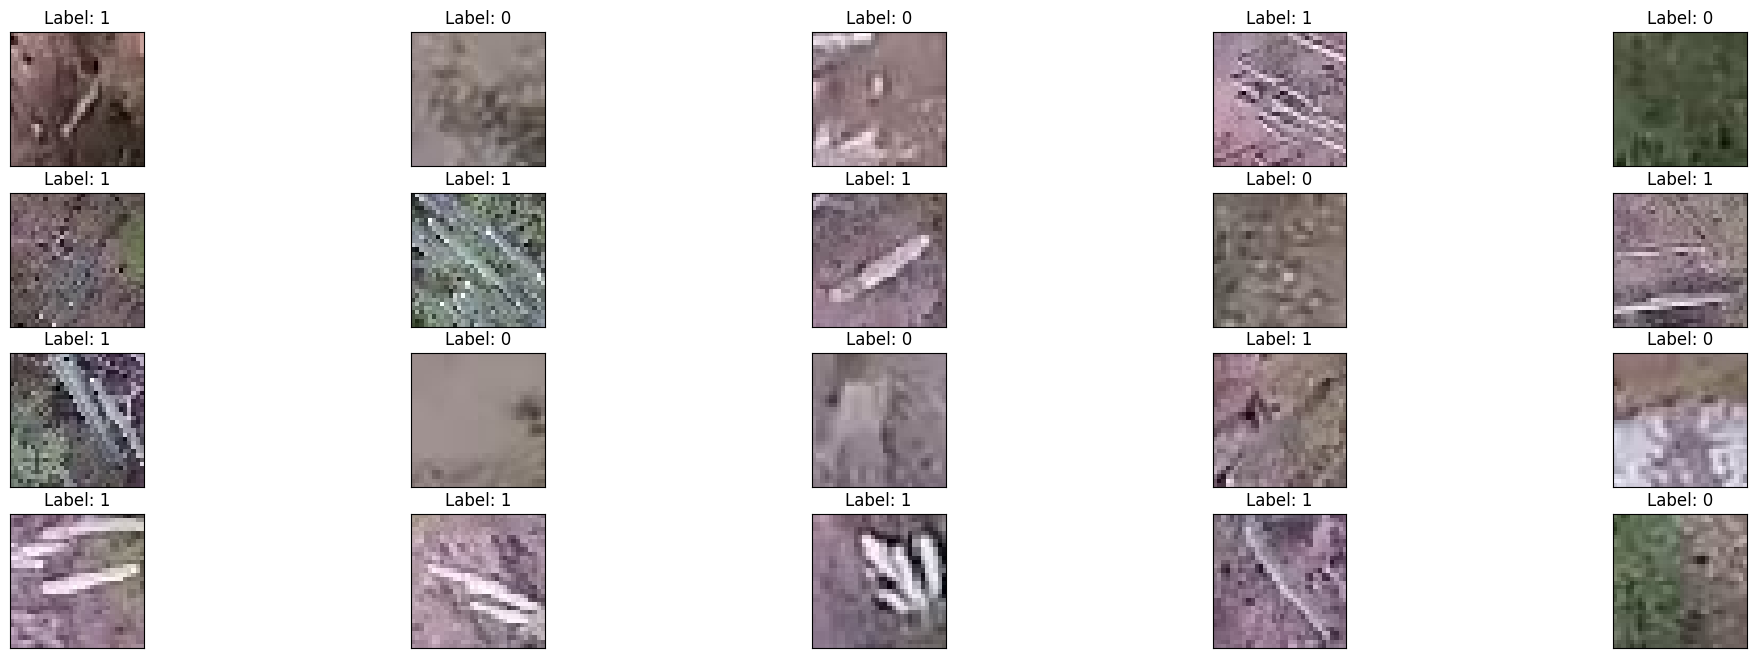

In [4]:
labels = pd.read_csv('../input/train.csv')
fig = plt.figure(figsize=(25, 8))
train_imgs = os.listdir("../input/train/train")
for idx, img in enumerate(np.random.choice(train_imgs, 20)):
    ax = fig.add_subplot(4, 20//4, idx+1, xticks=[], yticks=[])
    im = Image.open("../input/train/train/" + img)
    plt.imshow(im)
    lab = labels.loc[labels['id'] == img, 'has_cactus'].values[0]
    ax.set_title(f'Label: {lab}')


In [5]:
test_img = os.listdir('../input/test/test')
test_df = pd.DataFrame(test_img, columns=['id'])
test_df['has_cactus'] = -1
test_df['data_type'] = 'test'

labels['has_cactus'] = labels['has_cactus'].astype(int)
labels['data_type'] = 'train'

labels.head()


,id,has_cactus,data_type
0,2de8f189f1dce439766637e75df0ee27.jpg,1,train
1,36704d250f236238e7f996812c48235d.jpg,1,train
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1,train
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1,train
4,152491e0daf75c0e669400300ff7e645.jpg,1,train


In [6]:
labels.loc[labels['data_type'] == 'train', 'has_cactus'].value_counts()


has_cactus
1    10628
0     3547
Name: count, dtype: int64

In [7]:
# splitting data into train and validation
train, valid = train_test_split(labels, stratify=labels.has_cactus, test_size=0.2)


In [8]:
def reader_fn(i, row):
    image = cv2.imread(f"../input/{row['data_type']}/{row['data_type']}/{row['id']}")[:,:,::-1] # BGR -> RGB
    label = torch.Tensor([row["has_cactus"]])
    return {"image": image, "label": label}


In [9]:
def augs(p=0.5):
    return albumentations.Compose([
        albumentations.HorizontalFlip(),
        albumentations.VerticalFlip(),
        albumentations.RandomBrightness(),
    ], p=p)


In [10]:
def get_transforms(dataset_key, size, p):

    PRE_TFMS = Transformer(dataset_key, lambda x: cv2.resize(x, (size, size)))

    AUGS = Transformer(dataset_key, lambda x: augs()(image=x)["image"])

    NRM_TFMS = transforms.Compose([
        Transformer(dataset_key, to_torch()),
        Transformer(dataset_key, normalize())
    ])
    
    train_tfms = transforms.Compose([PRE_TFMS, AUGS, NRM_TFMS])
    val_tfms = transforms.Compose([PRE_TFMS, NRM_TFMS])
    
    return train_tfms, val_tfms


In [11]:
train_tfms, val_tfms = get_transforms("image", 32, 0.5)


NameError: name 'Transformer' is not defined

In [12]:
train_dk = DataKek(df=train, reader_fn=reader_fn, transforms=train_tfms)
val_dk = DataKek(df=valid, reader_fn=reader_fn, transforms=val_tfms)

batch_size = 64
workers = 0

train_dl = DataLoader(train_dk, batch_size=batch_size, num_workers=workers, shuffle=True, drop_last=True)
val_dl = DataLoader(val_dk, batch_size=batch_size, num_workers=workers, shuffle=False)


NameError: name 'DataKek' is not defined

In [13]:
test_dk = DataKek(df=test_df, reader_fn=reader_fn, transforms=val_tfms)
test_dl = DataLoader(test_dk, batch_size=batch_size, num_workers=workers, shuffle=False)


NameError: name 'DataKek' is not defined

In [14]:
class Net(nn.Module):
    def __init__(
            self,
            num_classes: int,
            p: float = 0.2,
            pooling_size: int = 2,
            last_conv_size: int = 1664,
            arch: str = "densenet169",
            pretrained: str = "imagenet") -> None:
        """A simple model to finetune.
        
        Args:
            num_classes: the number of target classes, the size of the last layer's output
            p: dropout probability
            pooling_size: the size of the result feature map after adaptive pooling layer
            last_conv_size: size of the flatten last backbone conv layer
            arch: the name of the architecture form pretrainedmodels
            pretrained: the mode for pretrained model from pretrainedmodels
        """
        super().__init__()
        net = pretrainedmodels.__dict__[arch](pretrained=pretrained)
        modules = list(net.children())[:-1]  # delete last layer
        # add custom head
        modules += [nn.Sequential(
            # AdaptiveConcatPool2d is a concat of AdaptiveMaxPooling and AdaptiveAveragePooling 
            # AdaptiveConcatPool2d(size=pooling_size),
            Flatten(),
            nn.BatchNorm1d(1664),
            nn.Dropout(p),
            nn.Linear(1664, num_classes)
        )]
        self.net = nn.Sequential(*modules)

    def forward(self, x):
        logits = self.net(x)
        return logits


In [15]:
dataowner = DataOwner(train_dl, val_dl, None)
model = Net(num_classes=1)
criterion = nn.BCEWithLogitsLoss()


NameError: name 'DataOwner' is not defined

In [16]:
def step_fn(model: torch.nn.Module,
            batch: torch.Tensor) -> torch.Tensor:
    """Determine what your model will do with your data.

    Args:
        model: the pytorch module to pass input in
        batch: the batch of data from the DataLoader

    Returns:
        The models forward pass results
    """
    
    inp = batch["image"]
    return model(inp)


In [17]:
def bce_accuracy(target: torch.Tensor,
                 preds: torch.Tensor,
                 thresh: bool = 0.5) -> float:
    target = target.cpu().detach().numpy()
    preds = (torch.sigmoid(preds).cpu().detach().numpy() > thresh).astype(int)
    return accuracy_score(target, preds)
  
def roc_auc(target: torch.Tensor,
                 preds: torch.Tensor) -> float:
    target = target.cpu().detach().numpy()
    preds = torch.sigmoid(preds).cpu().detach().numpy()
    return roc_auc_score(target, preds)


In [18]:
keker = Keker(model=model,
              dataowner=dataowner,
              criterion=criterion,
              step_fn=step_fn,
              target_key="label",
              metrics={"acc": bce_accuracy, 'auc': roc_auc},
              opt=torch.optim.SGD,
              opt_params={"momentum": 0.99})


NameError: name 'Keker' is not defined

In [19]:
keker.unfreeze(model_attr="net")

layer_num = -1
keker.freeze_to(layer_num, model_attr="net")


NameError: name 'keker' is not defined

In [20]:
keker.kek_one_cycle(max_lr=1e-2,                  # the maximum learning rate
                    cycle_len=5,                  # number of epochs, actually, but not exactly
                    momentum_range=(0.95, 0.85),  # range of momentum changes
                    div_factor=25,                # max_lr / min_lr
                    increase_fraction=0.3,        # the part of cycle when learning rate increases
                    logdir='train_logs')
keker.plot_kek('train_logs')


NameError: name 'keker' is not defined

In [21]:
keker.kek_one_cycle(max_lr=1e-3,                  # the maximum learning rate
                    cycle_len=5,                  # number of epochs, actually, but not exactly
                    momentum_range=(0.95, 0.85),  # range of momentum changes
                    div_factor=25,                # max_lr / min_lr
                    increase_fraction=0.2,        # the part of cycle when learning rate increases
                    logdir='train_logs1')
keker.plot_kek('train_logs1')


NameError: name 'keker' is not defined

In [22]:
preds = keker.predict_loader(loader=test_dl)


NameError: name 'keker' is not defined

In [23]:
# flip_ = albumentations.HorizontalFlip(always_apply=True)
# transpose_ = albumentations.Transpose(always_apply=True)

# def insert_aug(aug, dataset_key="image", size=224):    
#     PRE_TFMS = Transformer(dataset_key, lambda x: cv2.resize(x, (size, size)))
    
#     AUGS = Transformer(dataset_key, lambda x: aug(image=x)["image"])
    
#     NRM_TFMS = transforms.Compose([
#         Transformer(dataset_key, to_torch()),
#         Transformer(dataset_key, normalize())
#     ])
    
#     tfm = transforms.Compose([PRE_TFMS, AUGS, NRM_TFMS])
#     return tfm

# flip = insert_aug(flip_)
# transpose = insert_aug(transpose_)

# tta_tfms = {"flip": flip, "transpose": transpose}

# # third, run TTA
# keker.TTA(loader=test_dl,                # loader to predict on 
#           tfms=tta_tfms,                # list or dict of always applying transforms
#           savedir="tta_preds1",  # savedir
#           prefix="preds")               # (optional) name prefix. default is 'preds'


In [24]:
# prediction = np.zeros((test_df.shape[0], 1))
# for i in os.listdir('tta_preds1'):
#     pr = np.load('tta_preds1/' + i)
#     prediction += pr
# prediction = prediction / len(os.listdir('tta_preds1'))


In [25]:
test_preds = pd.DataFrame({'imgs': test_df.id.values, 'preds': preds.reshape(-1,)})
test_preds.columns = ['id', 'has_cactus']
test_preds.to_csv('sub.csv', index=False)
test_preds.head()


NameError: name 'preds' is not defined